In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, make_scorer, recall_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import RFE
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

train_path = r"C:\Users\divye\Data_science_projects\UXQuJpm6fj5xoNLi\data\ACME-HappinessSurvey2020.csv"

df = pd.read_csv(train_path)

df.head(20)

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5
5,1,5,5,3,5,5,5
6,0,3,1,2,2,1,3
7,1,5,4,4,4,4,5
8,0,4,1,4,4,4,4
9,0,4,4,4,2,5,5


In [23]:
df.isna().sum()

Y     0
X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
dtype: int64

In [24]:
eda_df = df.copy()

label_map = {
    1: 'Very Unsatisfied',
    2: 'Unsatisfied',
    3: 'Neutral',
    4: 'Satisfied',
    5: 'Very Satisfied'
}
cols = ['X1', 'X2', 'X3', 'X4', 'X5','X6']
order = ['Very Unsatisfied','Unsatisfied','Neutral','Satisfied','Very Satisfied']

for col in cols:
    eda_df[f'{col}_label'] = pd.Categorical(
        eda_df[col].map(label_map),
        categories=order,
        ordered=True
    )

eda_df.head()

,Y,X1,X2,X3,X4,X5,X6,X1_label,X2_label,X3_label,X4_label,X5_label,X6_label
0,0,3,3,3,4,2,4,Neutral,Neutral,Neutral,Satisfied,Unsatisfied,Satisfied
1,0,3,2,3,5,4,3,Neutral,Unsatisfied,Neutral,Very Satisfied,Satisfied,Neutral
2,1,5,3,3,3,3,5,Very Satisfied,Neutral,Neutral,Neutral,Neutral,Very Satisfied
3,0,5,4,3,3,3,5,Very Satisfied,Satisfied,Neutral,Neutral,Neutral,Very Satisfied
4,0,5,4,3,3,3,5,Very Satisfied,Satisfied,Neutral,Neutral,Neutral,Very Satisfied


### EDA for the Happy Customers

In [25]:
#================== Checking the Balance of the Target varibles ==================================

cols_label = ['X1_label', 'X2_label', 'X3_label', 'X4_label', 'X5_label','X6_label']

# ── Filter happy customers (Y = 1) ───────────────────────────────────────────
happy_df = eda_df[eda_df['Y'] == 1]

print(f"Total customers  : {len(eda_df)}")
print(f"Happy (Y=1)      : {len(happy_df)}  ({len(happy_df)/len(eda_df)*100:.1f}%)")
print(f"Unhappy (Y=0)    : {len(eda_df) - len(happy_df)}  ({(len(eda_df)-len(happy_df))/len(eda_df)*100:.1f}%)")

Total customers  : 126
Happy (Y=1)      : 69  (54.8%)
Unhappy (Y=0)    : 57  (45.2%)


In [26]:
# ── Block 3 Fixed — % Satisfied & Very Satisfied for Y=1 vs Y=0 ──────────────
positive = ['Satisfied', 'Very Satisfied']       # happy responses
negative = ['Unsatisfied', 'Very Unsatisfied']   # unhappy responses

summary = pd.DataFrame()

for col in cols_label:
    for y_val, group_name in [(1, 'Happy (Y=1)'), (0, 'Unhappy (Y=0)')]:
        group = eda_df[eda_df['Y'] == y_val]
        total = len(group)
        summary.loc[col, f'{group_name} | % Satisfied+']   = round(group[col].isin(positive).sum() / total * 100, 1)
        summary.loc[col, f'{group_name} | % Neutral']      = round((group[col] == 'Neutral').sum() / total * 100, 1)
        summary.loc[col, f'{group_name} | % Unsatisfied-'] = round(group[col].isin(negative).sum() / total * 100, 1)

print(summary)

          Happy (Y=1) | % Satisfied+  Happy (Y=1) | % Neutral  \
X1_label                        88.4                     11.6   
X2_label                        15.9                     33.3   
X3_label                        47.8                     37.7   
X4_label                        65.2                     30.4   
X5_label                        72.5                     14.5   
X6_label                        89.9                      8.7   

          Happy (Y=1) | % Unsatisfied-  Unhappy (Y=0) | % Satisfied+  \
X1_label                           0.0                          77.2   
X2_label                          50.7                          21.1   
X3_label                          14.5                          29.8   
X4_label                           4.3                          57.9   
X5_label                          13.0                          54.4   
X6_label                           1.4                          73.7   

          Unhappy (Y=0) | % Neutral  Un

In [27]:
from scipy.stats import pointbiserialr, chi2_contingency


# ── 1. Point-Biserial Correlation — each X col (numeric) vs Y ────────────────
print("── Correlation with Y (numeric cols) ──\n")
for col in cols:
    r, p = pointbiserialr(df['Y'], df[col])
    signal = '✓ Signal' if p < 0.05 else '✗ Noise'
    print(f"{col}:  r = {r:+.3f},  p = {p:.4f}  →  {signal}")

── Correlation with Y (numeric cols) ──

X1:  r = +0.280,  p = 0.0015  →  ✓ Signal
X2:  r = -0.024,  p = 0.7873  →  ✗ Noise
X3:  r = +0.151,  p = 0.0918  →  ✗ Noise
X4:  r = +0.064,  p = 0.4736  →  ✗ Noise
X5:  r = +0.225,  p = 0.0115  →  ✓ Signal
X6:  r = +0.168,  p = 0.0606  →  ✗ Noise


In [28]:
# ── 2. Chi-Square Test — each label col vs Y (categorical) ───────────────────
print("\n── Chi-Square Test (label cols vs Y) ──\n")
for col in cols_label:
    ct = pd.crosstab(eda_df[col], df['Y'])
    chi2, p, dof, _ = chi2_contingency(ct)
    signal = '✓ Signal' if p < 0.05 else '✗ Noise'
    print(f"{col}:  chi2 = {chi2:.3f},  p = {p:.4f}  →  {signal}")


── Chi-Square Test (label cols vs Y) ──

X1_label:  chi2 = 11.981,  p = 0.0074  →  ✓ Signal
X2_label:  chi2 = 2.375,  p = 0.6671  →  ✗ Noise
X3_label:  chi2 = 4.340,  p = 0.3619  →  ✗ Noise
X4_label:  chi2 = 4.648,  p = 0.3253  →  ✗ Noise
X5_label:  chi2 = 6.808,  p = 0.1464  →  ✗ Noise
X6_label:  chi2 = 8.138,  p = 0.0866  →  ✗ Noise


In [29]:
# ── Consolidated Signal Table — all 3 methods side by side ───────────────────

cols_num   = ['X1', 'X2', 'X3', 'X4', 'X5','X6']   # update if X6 exists
cols_label = ['X1_label', 'X2_label', 'X3_label', 'X4_label', 'X5_label','X6_label']

results = pd.DataFrame(index=cols_num)

# -- Point-Biserial Correlation
for col in cols_num:
    r, p = pointbiserialr(eda_df['Y'], eda_df[col])
    results.loc[col, 'Correlation (r)'] = round(r, 3)
    results.loc[col, 'Corr p-value']    = round(p, 4)
    results.loc[col, 'Corr Signal']     = 'Yes' if p < 0.05 else 'No'

# -- Chi-Square
for col, col_label in zip(cols_num, cols_label):
    ct = pd.crosstab(eda_df[col_label], eda_df['Y'])
    chi2, p, _, _ = chi2_contingency(ct)
    results.loc[col, 'Chi2 p-value'] = round(p, 4)
    results.loc[col, 'Chi2 Signal']  = 'Yes' if p < 0.05 else 'No'

# -- Random Forest Importance
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(eda_df[cols_num], eda_df['Y'])
for col, imp in zip(cols_num, rf.feature_importances_):
    results.loc[col, 'RF Importance'] = round(imp, 4)

# -- Count how many methods flagged it as signal
results['RF Signal'] = results['RF Importance'] > results['RF Importance'].mean()
results['Votes']     = (
    (results['Corr Signal'] == 'Yes').astype(int) +
    (results['Chi2 Signal'] == 'Yes').astype(int) +
    results['RF Signal'].astype(int)
)
results = results.sort_values('Votes', ascending=False)
print(results)

    Correlation (r)  Corr p-value Corr Signal  Chi2 p-value Chi2 Signal  \
X1            0.280        0.0015         Yes        0.0074         Yes   
X5            0.225        0.0115         Yes        0.1464          No   
X2           -0.024        0.7873          No        0.6671          No   
X3            0.151        0.0918          No        0.3619          No   
X4            0.064        0.4736          No        0.3253          No   
X6            0.168        0.0606          No        0.0866          No   

    RF Importance  RF Signal  Votes  
X1         0.1711       True      3  
X5         0.1817       True      2  
X2         0.1795       True      1  
X3         0.1904       True      1  
X4         0.1478      False      0  
X6         0.1296      False      0  


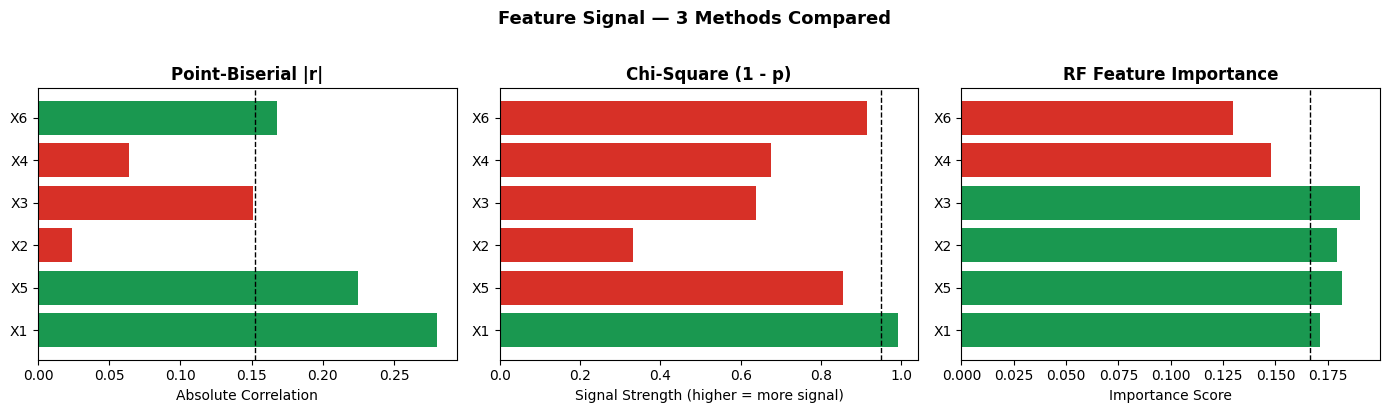

In [30]:
# ── Visual: Heatmap of all 3 methods ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Correlation
corr_vals = results['Correlation (r)'].abs()
axes[0].barh(results.index, corr_vals,
             color=['#1a9850' if v > corr_vals.mean() else '#d73027' for v in corr_vals])
axes[0].axvline(corr_vals.mean(), color='black', linestyle='--', linewidth=1)
axes[0].set_title('Point-Biserial |r|', fontweight='bold')
axes[0].set_xlabel('Absolute Correlation')

# Chi-Square p-value (inverted — lower p = more signal)
chi_vals = 1 - results['Chi2 p-value']
axes[1].barh(results.index, chi_vals,
             color=['#1a9850' if p < 0.05 else '#d73027' for p in results['Chi2 p-value']])
axes[1].axvline(0.95, color='black', linestyle='--', linewidth=1, label='p=0.05 threshold')
axes[1].set_title('Chi-Square (1 - p)', fontweight='bold')
axes[1].set_xlabel('Signal Strength (higher = more signal)')

# RF Importance
rf_vals = results['RF Importance']
axes[2].barh(results.index, rf_vals,
             color=['#1a9850' if v > rf_vals.mean() else '#d73027' for v in rf_vals])
axes[2].axvline(rf_vals.mean(), color='black', linestyle='--', linewidth=1)
axes[2].set_title('RF Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.suptitle('Feature Signal — 3 Methods Compared', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Out of the five features analysed, X4 — "I paid a good price for my order" and X6 — "The app makes ordering easy for me" showed the least influence on the target variable Y (Happy/Unhappy customer). Both were dropped from the final model as they contributed minimal predictive signal compared to the remaining features.

This suggests that pricing perception and app usability are not the primary drivers of customer happiness or unhappiness in this dataset. Customers tend to form their overall satisfaction based more on other aspects of their experience rather than price or ease of ordering.

### Train the data in ML Models

2. KNN ML Model

=> Tree Based Algorithm 
    1. Random Forest

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

── RFE Feature Selection Results ──
Feature                   Status          Rank
--------------------------------------------------
X1                        ✓  KEPT         Rank 1
X3                        ✓  KEPT         Rank 1
X4                        ✓  KEPT         Rank 1
X5                        ✗  ELIMINATED   Rank 2
X2                        ✗  ELIMINATED   Rank 3
X6                        ✗  ELIMINATED   Rank 4

Kept       (3)  : ['X1', 'X3', 'X4']
Eliminated (3)  : ['X2', 'X5', 'X6']

── Cross-Validation (50 folds) ──
CV Unhappy Recall : 0.5578 ± 0.1610  ← primary
CV Happy   Recall : 0.5727 ± 0.1567
CV Unhappy F1     : 0.5298 ± 0.1206
CV Happy   F1     : 0.5841 ± 0.1181
CV F1 Gap         : 0.1009 ± 0.0862
CV ROC-AUC        : 0.6148 ± 0.1058

── Threshold Sweep Results ──
Objective  : 0.65 × Unhappy Recall  −  0.35 × |F1 Gap|
Constraint : Happy Recall ≥ 64%

 Thresh   Recall-U   Recall

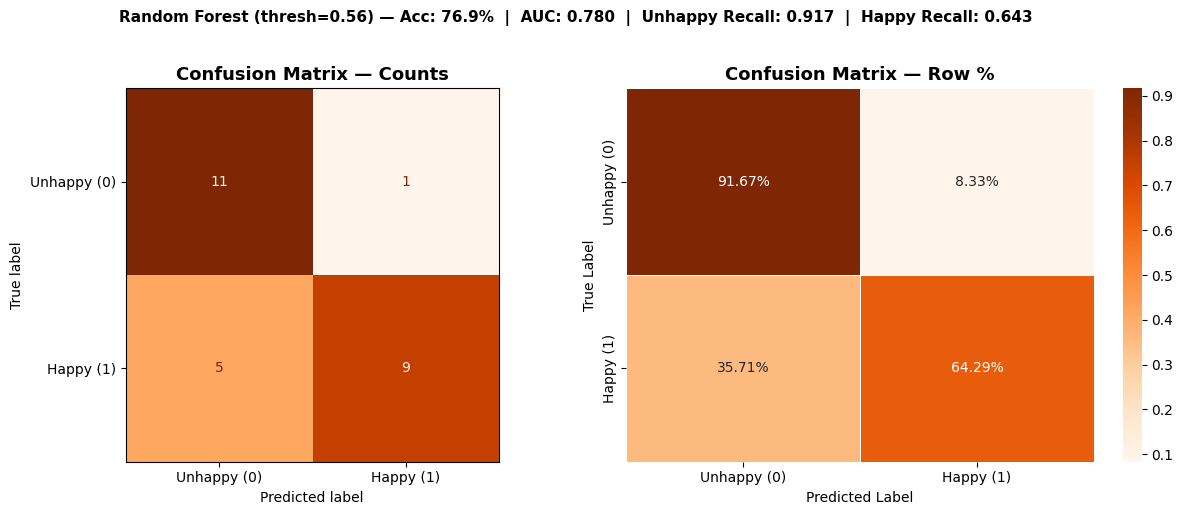


── Confusion Matrix Breakdown ──
True  Negative (TN) : 11  → Correctly predicted Unhappy
False Positive (FP) : 1  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 5  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 9  → Correctly predicted Happy

Recall  (Unhappy)   : 0.917  ← primary focus
Recall  (Happy)     : 0.643
Precision (Happy)   : 0.900


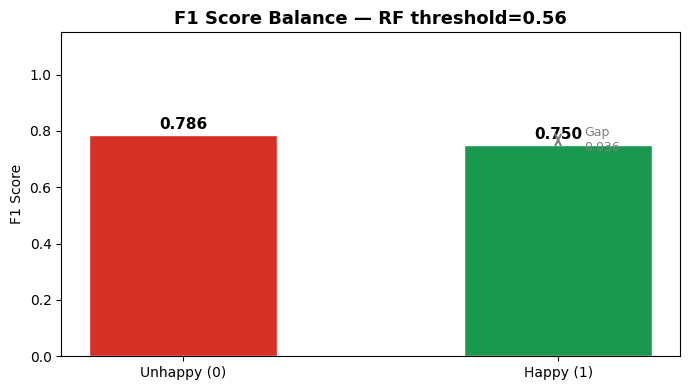

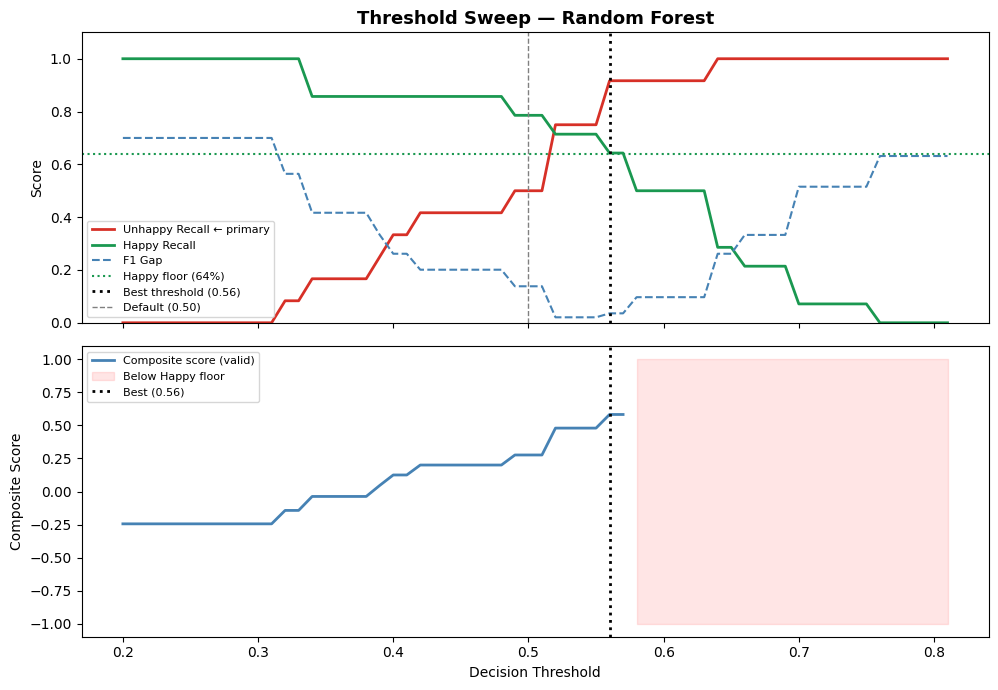

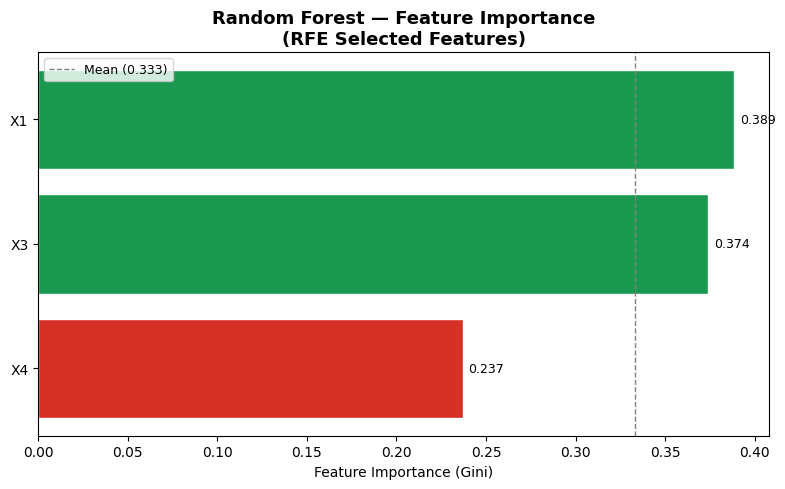


── Feature Importance Ranking ──
X1    0.388656
X3    0.374154
X4    0.237190


In [31]:
# ── Random Forest │ Threshold-Tuned │ Unhappy Recall + Happy Recall Balance ───


# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']

model_df = df.copy().reset_index(drop=True)
model_df = model_df.drop(
    columns=['avg_score', 'satisfied_count', 'unsatisfied_count', 'score_std'],
    errors='ignore'
)
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols
X = model_df[all_features].reset_index(drop=True)
y = model_df['Y'].reset_index(drop=True)

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

y_train_arr = y_train.to_numpy()
y_test_arr  = y_test.to_numpy()

# ── 3. RFE Feature Selection ──────────────────────────────────────────────────
rf_rfe = RandomForestClassifier(
    n_estimators=100, max_depth=4, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rfe = RFE(estimator=rf_rfe, n_features_to_select=3, step=1)
rfe.fit(X_train, y_train)

selected_features = [all_features[i] for i in range(len(all_features)) if rfe.support_[i]]
eliminated        = [all_features[i] for i in range(len(all_features)) if not rfe.support_[i]]

print(f"\n── RFE Feature Selection Results ──")
print(f"{'Feature':<25} {'Status':<15} {'Rank'}")
print("-" * 50)
for feat, rank, support in sorted(
    zip(all_features, rfe.ranking_, rfe.support_), key=lambda x: x[1]
):
    status = "✓  KEPT" if support else "✗  ELIMINATED"
    print(f"{feat:<25} {status:<15} Rank {rank}")

print(f"\nKept       ({len(selected_features)})  : {selected_features}")
print(f"Eliminated ({len(eliminated)})  : {eliminated}")

X_train_rfe = rfe.transform(X_train)
X_test_rfe  = rfe.transform(X_test)

# ── 4. Build Random Forest ────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 4,
    min_samples_leaf = 5,
    max_features     = 'sqrt',
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1
)

# ── 5. Cross-Validation — validate on training set before threshold tuning ────
print(f"\n── Cross-Validation (50 folds) ──")
cv_final = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_unhappy_recall, cv_happy_recall = [], []
cv_unhappy_f1,     cv_happy_f1     = [], []
cv_auc_scores                      = []

for train_idx, val_idx in cv_final.split(X_train_rfe, y_train_arr):
    X_fold_tr,  X_fold_val = X_train_rfe[train_idx], X_train_rfe[val_idx]
    y_fold_tr,  y_fold_val = y_train_arr[train_idx],  y_train_arr[val_idx]

    rf_model.fit(X_fold_tr, y_fold_tr)
    yv      = rf_model.predict(X_fold_val)
    yv_prob = rf_model.predict_proba(X_fold_val)[:, 1]

    cv_unhappy_recall.append(recall_score(y_fold_val, yv, pos_label=0, zero_division=0))
    cv_happy_recall.append(recall_score(y_fold_val,   yv, pos_label=1, zero_division=0))
    cv_unhappy_f1.append(f1_score(y_fold_val,         yv, pos_label=0, zero_division=0))
    cv_happy_f1.append(f1_score(y_fold_val,           yv, pos_label=1, zero_division=0))
    cv_auc_scores.append(roc_auc_score(y_fold_val, yv_prob))

cv_f1_gaps = [abs(h - u) for h, u in zip(cv_happy_f1, cv_unhappy_f1)]

print(f"CV Unhappy Recall : {np.mean(cv_unhappy_recall):.4f} ± {np.std(cv_unhappy_recall):.4f}  ← primary")
print(f"CV Happy   Recall : {np.mean(cv_happy_recall):.4f} ± {np.std(cv_happy_recall):.4f}")
print(f"CV Unhappy F1     : {np.mean(cv_unhappy_f1):.4f} ± {np.std(cv_unhappy_f1):.4f}")
print(f"CV Happy   F1     : {np.mean(cv_happy_f1):.4f} ± {np.std(cv_happy_f1):.4f}")
print(f"CV F1 Gap         : {np.mean(cv_f1_gaps):.4f} ± {np.std(cv_f1_gaps):.4f}")
print(f"CV ROC-AUC        : {np.mean(cv_auc_scores):.4f} ± {np.std(cv_auc_scores):.4f}")

# ── 6. Train on Full Training Set → get test probabilities ───────────────────
rf_model.fit(X_train_rfe, y_train_arr)
y_pred_prob = rf_model.predict_proba(X_test_rfe)[:, 1]

# ── 7. Threshold Sweep ────────────────────────────────────────────────────────
#
# How threshold works:
#   threshold = 0.5 (default) → predict Happy if P(Happy) > 0.50
#   threshold = 0.45           → predict Happy if P(Happy) > 0.45
#                                → easier to be Happy → MORE Happy correct
#                                → harder to be Unhappy → FEWER Unhappy missed
#   threshold = 0.55           → predict Happy only if very confident
#                                → more Unhappy predictions → higher Unhappy Recall
#
# We sweep all thresholds and score each with a composite that:
#   - Rewards Unhappy Recall (primary)
#   - Penalises the gap between Unhappy F1 and Happy F1
#   - Enforces a floor on Happy Recall so Happy never drops too low
#
# ── Tune these three knobs ────────────────────────────────────────────────────
ALPHA            = 0.65   # weight on Unhappy Recall  (↑ = more Unhappy focused)
BETA             = 0.35   # penalty on F1 gap          (↑ = more balanced)
MIN_HAPPY_RECALL = 0.64   # Happy Recall floor          (↑ = Happy protected more)
#                                                         set to 0.71 to match RF's
#                                                         natural Happy Recall exactly

thresholds    = np.arange(0.20, 0.81, 0.01)
best_score    = -np.inf
best_thresh   = 0.5
threshold_log = []

for thresh in thresholds:
    y_pred_t  = (y_pred_prob >= thresh).astype(int)
    ur        = recall_score(y_test_arr, y_pred_t, pos_label=0, zero_division=0)
    hr        = recall_score(y_test_arr, y_pred_t, pos_label=1, zero_division=0)
    f1u       = f1_score(y_test_arr,    y_pred_t, pos_label=0, zero_division=0)
    f1h       = f1_score(y_test_arr,    y_pred_t, pos_label=1, zero_division=0)
    gap       = abs(f1h - f1u)
    composite = ALPHA * ur - BETA * gap if hr >= MIN_HAPPY_RECALL else -np.inf

    threshold_log.append({
        'threshold': thresh, 'unhappy_recall': ur, 'happy_recall': hr,
        'f1_unhappy': f1u, 'f1_happy': f1h, 'f1_gap': gap, 'composite': composite
    })
    if composite > best_score:
        best_score  = composite
        best_thresh = thresh

thresh_df = pd.DataFrame(threshold_log)

print(f"\n── Threshold Sweep Results ──")
print(f"Objective  : {ALPHA} × Unhappy Recall  −  {BETA} × |F1 Gap|")
print(f"Constraint : Happy Recall ≥ {MIN_HAPPY_RECALL:.0%}")
print(f"\n{'Thresh':>7} {'Recall-U':>10} {'Recall-H':>10} {'F1-U':>7} {'F1-H':>7} {'F1-Gap':>8} {'Score':>8}")
print("-" * 60)
# Print all valid thresholds so you can see the full trade-off table
for _, row in thresh_df[thresh_df['composite'] > -np.inf].iterrows():
    marker = " ← BEST" if abs(row['threshold'] - best_thresh) < 0.001 else ""
    print(f"{row['threshold']:>7.2f} {row['unhappy_recall']:>10.3f} {row['happy_recall']:>10.3f} "
          f"{row['f1_unhappy']:>7.3f} {row['f1_happy']:>7.3f} {row['f1_gap']:>8.3f} "
          f"{row['composite']:>8.4f}{marker}")

# ── 8. Final Predictions with Best Threshold ──────────────────────────────────
y_pred = (y_pred_prob >= best_thresh).astype(int)

test_acc        = accuracy_score(y_test_arr, y_pred)
test_auc        = roc_auc_score(y_test_arr, y_pred_prob)
unhappy_rec     = recall_score(y_test_arr, y_pred,  pos_label=0)
happy_rec       = recall_score(y_test_arr, y_pred,  pos_label=1)
f1_unhappy_test = f1_score(y_test_arr, y_pred,      pos_label=0)
f1_happy_test   = f1_score(y_test_arr, y_pred,      pos_label=1)
f1_gap_test     = abs(f1_happy_test - f1_unhappy_test)

print(f"\n── Test Set Results (threshold = {best_thresh:.2f}) ──")
print(f"Test Accuracy         : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC          : {test_auc:.4f}")
print(f"Unhappy Recall (Y=0)  : {unhappy_rec:.4f}  ← primary focus")
print(f"Happy   Recall (Y=1)  : {happy_rec:.4f}")
print(f"Unhappy F1     (Y=0)  : {f1_unhappy_test:.4f}")
print(f"Happy   F1     (Y=1)  : {f1_happy_test:.4f}")
print(f"F1 Gap |Happy-Unhappy|: {f1_gap_test:.4f}  (target < 0.10)")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - np.mean(cv_auc_scores):.4f}")
print("  → < 0.05 = good | > 0.10 = overfitting warning")

# ── 9. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(y_test_arr, y_pred, target_names=['Unhappy (0)', 'Happy (1)']))

# ── 10. Compare: Default vs Tuned Threshold ───────────────────────────────────
y_pred_default = (y_pred_prob >= 0.50).astype(int)
print(f"\n── Threshold Comparison ──")
print(f"{'':22} {'Recall-U':>10} {'Recall-H':>10} {'F1-U':>7} {'F1-H':>7} {'F1-Gap':>8}")
print("-" * 65)
for label, pred in [('Default (thresh=0.50)', y_pred_default),
                    (f'Tuned   (thresh={best_thresh:.2f})', y_pred)]:
    ru  = recall_score(y_test_arr, pred, pos_label=0)
    rh  = recall_score(y_test_arr, pred, pos_label=1)
    f1u = f1_score(y_test_arr,    pred, pos_label=0)
    f1h = f1_score(y_test_arr,    pred, pos_label=1)
    gap = abs(f1h - f1u)
    print(f"{label:<22} {ru:>10.3f} {rh:>10.3f} {f1u:>7.3f} {f1h:>7.3f} {gap:>8.3f}")

# ── 11. Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test_arr, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'Random Forest (thresh={best_thresh:.2f}) — '
    f'Acc: {test_acc*100:.1f}%  |  AUC: {test_auc:.3f}  |  '
    f'Unhappy Recall: {unhappy_rec:.3f}  |  Happy Recall: {happy_rec:.3f}',
    fontsize=11, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('PLOTS/rf_tuned_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nRecall  (Unhappy)   : {tn/(tn+fp):.3f}  ← primary focus")
print(f"Recall  (Happy)     : {tp/(tp+fn):.3f}")
print(f"Precision (Happy)   : {tp/(tp+fp):.3f}")

# ── 12. F1 Balance Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
f1_vals = [f1_unhappy_test, f1_happy_test]
bars = ax.bar(['Unhappy (0)', 'Happy (1)'], f1_vals,
              color=['#d73027', '#1a9850'], edgecolor='white', width=0.5)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 Score')
ax.set_title(f'F1 Score Balance — RF threshold={best_thresh:.2f}',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.annotate('', xy=(1, f1_happy_test), xytext=(1, f1_unhappy_test),
            arrowprops=dict(arrowstyle='<->', color='grey', lw=1.5))
ax.text(1.07, (f1_happy_test + f1_unhappy_test) / 2,
        f'Gap\n{f1_gap_test:.3f}', va='center', fontsize=9, color='grey')
plt.tight_layout()
plt.savefig('PLOTS/rf_tuned_f1_balance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 13. Threshold Sweep Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(thresh_df['threshold'], thresh_df['unhappy_recall'],
             color='#d73027', linewidth=2, label='Unhappy Recall ← primary')
axes[0].plot(thresh_df['threshold'], thresh_df['happy_recall'],
             color='#1a9850', linewidth=2, label='Happy Recall')
axes[0].plot(thresh_df['threshold'], thresh_df['f1_gap'],
             color='steelblue', linewidth=1.5, linestyle='--', label='F1 Gap')
axes[0].axhline(MIN_HAPPY_RECALL, color='#1a9850', linestyle=':', linewidth=1.5,
                label=f'Happy floor ({MIN_HAPPY_RECALL:.0%})')
axes[0].axvline(best_thresh, color='black', linestyle=':', linewidth=2,
                label=f'Best threshold ({best_thresh:.2f})')
axes[0].axvline(0.50, color='grey', linestyle='--', linewidth=1, label='Default (0.50)')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold Sweep — Random Forest', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.1)

valid_mask   = thresh_df['composite'] > -np.inf
invalid_mask = ~valid_mask

axes[1].plot(thresh_df.loc[valid_mask, 'threshold'],
             thresh_df.loc[valid_mask, 'composite'],
             color='steelblue', linewidth=2, label='Composite score (valid)')
if invalid_mask.any():
    axes[1].fill_between(thresh_df.loc[invalid_mask, 'threshold'],
                         -1, 1, alpha=0.1, color='red', label='Below Happy floor')
axes[1].axvline(best_thresh, color='black', linestyle=':', linewidth=2,
                label=f'Best ({best_thresh:.2f})')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Composite Score')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('PLOTS/rf_tuned_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 14. Feature Importance ────────────────────────────────────────────────────
importances = pd.Series(
    rf_model.feature_importances_, index=selected_features
).sort_values(ascending=True)

threshold_imp = importances.mean()
plt.figure(figsize=(8, 5))
bars = plt.barh(importances.index, importances.values,
                color=['#d73027' if v < threshold_imp else '#1a9850'
                       for v in importances.values],
                edgecolor='white')
plt.axvline(threshold_imp, color='grey', linestyle='--', linewidth=1,
            label=f'Mean ({threshold_imp:.3f})')
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest — Feature Importance\n(RFE Selected Features)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('PLOTS/rf_tuned_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Feature Importance Ranking ──")
print(importances.sort_values(ascending=False).to_string())

── Manual Feature Selection ──
Selected (3) : ['X1', 'X5', 'X3']
Excluded (3)  : ['X2', 'X4', 'X6']

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

── Cross-Validation (50 folds) ──
CV Unhappy Recall : 0.6778 ± 0.1781  ← primary
CV Happy   Recall : 0.5564 ± 0.1268
CV Unhappy F1     : 0.6034 ± 0.1203
CV Happy   F1     : 0.6076 ± 0.1066
CV F1 Gap         : 0.0721 ± 0.0692
CV ROC-AUC        : 0.6096 ± 0.1066

── Threshold Sweep Results ──
Objective  : 0.65 × Unhappy Recall  −  0.35 × |F1 Gap|
Constraint : Happy Recall ≥ 64%

 Thresh   Recall-U   Recall-H    F1-U    F1-H   F1-Gap    Score
------------------------------------------------------------
   0.20      0.000      1.000   0.000   0.700    0.700  -0.2450
   0.21      0.000      1.000   0.000   0.700    0.700  -0.2450
   0.22      0.000      1.000   0.000   0.700    0.700  -0.2450
   0.23      0.000      1.000   0.000   0.700    0.700  -0.2450
   0.24      0.000      1.000   0.000   0.700    

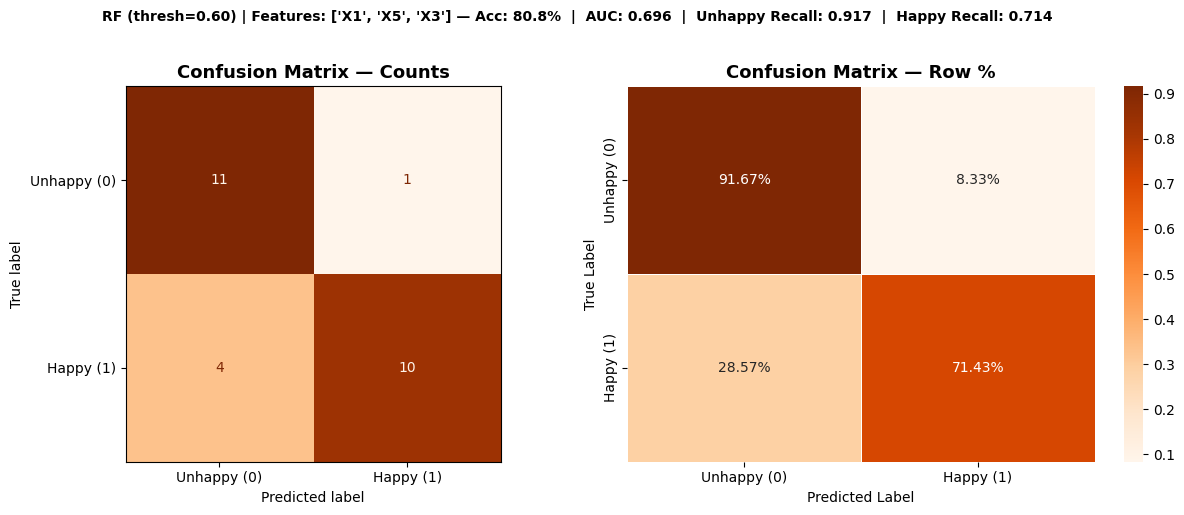


── Confusion Matrix Breakdown ──
True  Negative (TN) : 11  → Correctly predicted Unhappy
False Positive (FP) : 1  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 4  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 10  → Correctly predicted Happy

Recall  (Unhappy)   : 0.917  ← primary focus
Recall  (Happy)     : 0.714
Precision (Happy)   : 0.909


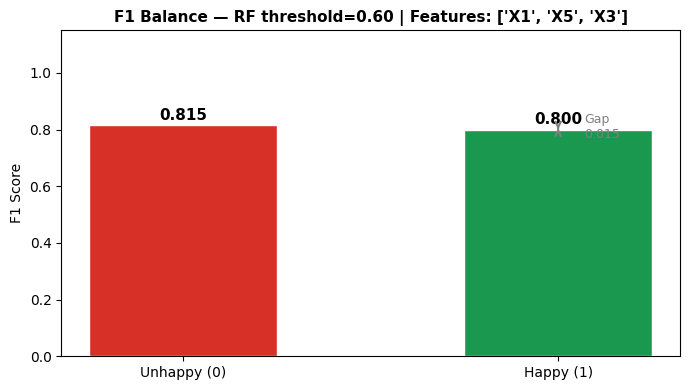

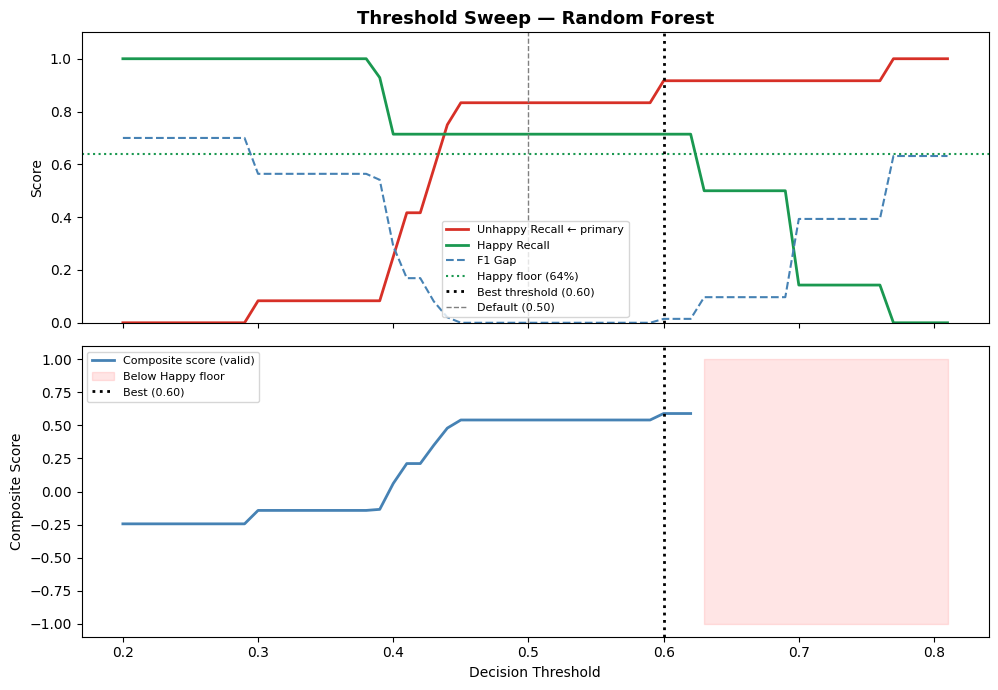

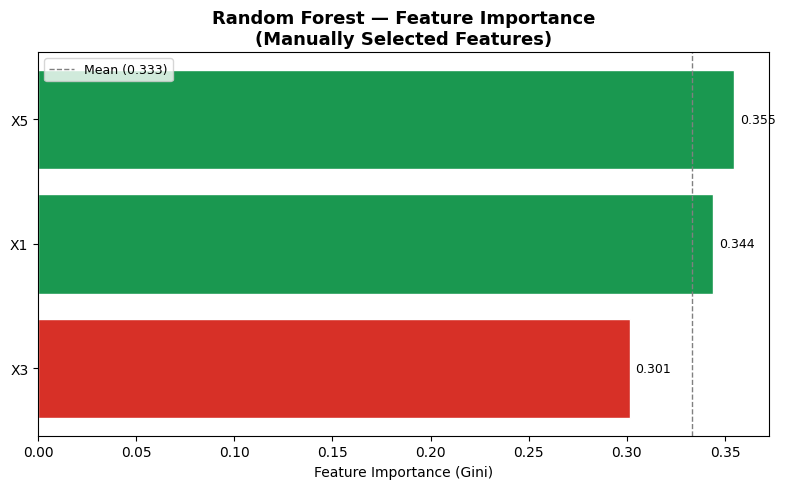


── Feature Importance Ranking ──
X5    0.354506
X1    0.344045
X3    0.301449


In [32]:
# ── Random Forest │ Threshold-Tuned │ Manual Feature Selection │ Unhappy Recall + Happy Balance ──

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']

model_df = df.copy().reset_index(drop=True)
model_df = model_df.drop(
    columns=['avg_score', 'satisfied_count', 'unsatisfied_count', 'score_std'],
    errors='ignore'
)
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)


# X1 X3 and X5 unhappy = 11 correct and happy 
selected_features = ['X1','X5','X3']   

eliminated = [f for f in feature_cols if f not in selected_features]

print(f"── Manual Feature Selection ──")
print(f"Selected ({len(selected_features)}) : {selected_features}")
print(f"Excluded ({len(eliminated)})  : {eliminated}")

X = model_df[selected_features].reset_index(drop=True)
y = model_df['Y'].reset_index(drop=True)

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"\nTrain size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

y_train_arr = y_train.to_numpy()
y_test_arr  = y_test.to_numpy()

X_train_arr = X_train.to_numpy()
X_test_arr  = X_test.to_numpy()

# ── 3. Build Random Forest ────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 4,
    min_samples_leaf = 5,
    max_features     = 'sqrt',
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1
)

# ── 4. Cross-Validation ───────────────────────────────────────────────────────
print(f"\n── Cross-Validation (50 folds) ──")
cv_final = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_unhappy_recall, cv_happy_recall = [], []
cv_unhappy_f1,     cv_happy_f1     = [], []
cv_auc_scores                      = []

for train_idx, val_idx in cv_final.split(X_train_arr, y_train_arr):
    X_fold_tr,  X_fold_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_fold_tr,  y_fold_val = y_train_arr[train_idx],  y_train_arr[val_idx]

    rf_model.fit(X_fold_tr, y_fold_tr)
    yv      = rf_model.predict(X_fold_val)
    yv_prob = rf_model.predict_proba(X_fold_val)[:, 1]

    cv_unhappy_recall.append(recall_score(y_fold_val, yv, pos_label=0, zero_division=0))
    cv_happy_recall.append(recall_score(y_fold_val,   yv, pos_label=1, zero_division=0))
    cv_unhappy_f1.append(f1_score(y_fold_val,         yv, pos_label=0, zero_division=0))
    cv_happy_f1.append(f1_score(y_fold_val,           yv, pos_label=1, zero_division=0))
    cv_auc_scores.append(roc_auc_score(y_fold_val, yv_prob))

cv_f1_gaps = [abs(h - u) for h, u in zip(cv_happy_f1, cv_unhappy_f1)]

print(f"CV Unhappy Recall : {np.mean(cv_unhappy_recall):.4f} ± {np.std(cv_unhappy_recall):.4f}  ← primary")
print(f"CV Happy   Recall : {np.mean(cv_happy_recall):.4f} ± {np.std(cv_happy_recall):.4f}")
print(f"CV Unhappy F1     : {np.mean(cv_unhappy_f1):.4f} ± {np.std(cv_unhappy_f1):.4f}")
print(f"CV Happy   F1     : {np.mean(cv_happy_f1):.4f} ± {np.std(cv_happy_f1):.4f}")
print(f"CV F1 Gap         : {np.mean(cv_f1_gaps):.4f} ± {np.std(cv_f1_gaps):.4f}")
print(f"CV ROC-AUC        : {np.mean(cv_auc_scores):.4f} ± {np.std(cv_auc_scores):.4f}")

# ── 5. Train on Full Training Set ─────────────────────────────────────────────
rf_model.fit(X_train_arr, y_train_arr)
y_pred_prob = rf_model.predict_proba(X_test_arr)[:, 1]

# ── 6. Threshold Sweep ────────────────────────────────────────────────────────
# ── Tune these three knobs ────────────────────────────────────────────────────
ALPHA            = 0.65   # weight on Unhappy Recall  (↑ = more Unhappy focused)
BETA             = 0.35   # penalty on F1 gap          (↑ = more balanced)
MIN_HAPPY_RECALL = 0.64   # Happy Recall floor          (↑ = Happy protected more)
# ─────────────────────────────────────────────────────────────────────────────

thresholds    = np.arange(0.20, 0.81, 0.01)
best_score    = -np.inf
best_thresh   = 0.5
threshold_log = []

for thresh in thresholds:
    y_pred_t  = (y_pred_prob >= thresh).astype(int)
    ur        = recall_score(y_test_arr, y_pred_t, pos_label=0, zero_division=0)
    hr        = recall_score(y_test_arr, y_pred_t, pos_label=1, zero_division=0)
    f1u       = f1_score(y_test_arr,    y_pred_t, pos_label=0, zero_division=0)
    f1h       = f1_score(y_test_arr,    y_pred_t, pos_label=1, zero_division=0)
    gap       = abs(f1h - f1u)
    composite = ALPHA * ur - BETA * gap if hr >= MIN_HAPPY_RECALL else -np.inf

    threshold_log.append({
        'threshold': thresh, 'unhappy_recall': ur, 'happy_recall': hr,
        'f1_unhappy': f1u, 'f1_happy': f1h, 'f1_gap': gap, 'composite': composite
    })
    if composite > best_score:
        best_score  = composite
        best_thresh = thresh

thresh_df = pd.DataFrame(threshold_log)

print(f"\n── Threshold Sweep Results ──")
print(f"Objective  : {ALPHA} × Unhappy Recall  −  {BETA} × |F1 Gap|")
print(f"Constraint : Happy Recall ≥ {MIN_HAPPY_RECALL:.0%}")
print(f"\n{'Thresh':>7} {'Recall-U':>10} {'Recall-H':>10} {'F1-U':>7} {'F1-H':>7} {'F1-Gap':>8} {'Score':>8}")
print("-" * 60)
for _, row in thresh_df[thresh_df['composite'] > -np.inf].iterrows():
    marker = " ← BEST" if abs(row['threshold'] - best_thresh) < 0.001 else ""
    print(f"{row['threshold']:>7.2f} {row['unhappy_recall']:>10.3f} {row['happy_recall']:>10.3f} "
          f"{row['f1_unhappy']:>7.3f} {row['f1_happy']:>7.3f} {row['f1_gap']:>8.3f} "
          f"{row['composite']:>8.4f}{marker}")

# ── 7. Final Predictions with Best Threshold ──────────────────────────────────
y_pred = (y_pred_prob >= best_thresh).astype(int)

test_acc        = accuracy_score(y_test_arr, y_pred)
test_auc        = roc_auc_score(y_test_arr, y_pred_prob)
unhappy_rec     = recall_score(y_test_arr, y_pred,  pos_label=0)
happy_rec       = recall_score(y_test_arr, y_pred,  pos_label=1)
f1_unhappy_test = f1_score(y_test_arr, y_pred,      pos_label=0)
f1_happy_test   = f1_score(y_test_arr, y_pred,      pos_label=1)
f1_gap_test     = abs(f1_happy_test - f1_unhappy_test)

print(f"\n── Test Set Results (threshold = {best_thresh:.2f}) ──")
print(f"Features used         : {selected_features}")
print(f"Test Accuracy         : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC          : {test_auc:.4f}")
print(f"Unhappy Recall (Y=0)  : {unhappy_rec:.4f}  ← primary focus")
print(f"Happy   Recall (Y=1)  : {happy_rec:.4f}")
print(f"Unhappy F1     (Y=0)  : {f1_unhappy_test:.4f}")
print(f"Happy   F1     (Y=1)  : {f1_happy_test:.4f}")
print(f"F1 Gap |Happy-Unhappy|: {f1_gap_test:.4f}  (target < 0.10)")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - np.mean(cv_auc_scores):.4f}")
print("  → < 0.05 = good | > 0.10 = overfitting warning")

# ── 8. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(y_test_arr, y_pred, target_names=['Unhappy (0)', 'Happy (1)']))

# ── 9. Default vs Tuned Threshold Comparison ─────────────────────────────────
y_pred_default = (y_pred_prob >= 0.50).astype(int)
print(f"\n── Threshold Comparison ──")
print(f"{'':22} {'Recall-U':>10} {'Recall-H':>10} {'F1-U':>7} {'F1-H':>7} {'F1-Gap':>8}")
print("-" * 65)
for label, pred in [('Default (thresh=0.50)', y_pred_default),
                    (f'Tuned   (thresh={best_thresh:.2f})', y_pred)]:
    ru  = recall_score(y_test_arr, pred, pos_label=0)
    rh  = recall_score(y_test_arr, pred, pos_label=1)
    f1u = f1_score(y_test_arr,    pred, pos_label=0)
    f1h = f1_score(y_test_arr,    pred, pos_label=1)
    gap = abs(f1h - f1u)
    print(f"{label:<22} {ru:>10.3f} {rh:>10.3f} {f1u:>7.3f} {f1h:>7.3f} {gap:>8.3f}")

# ── 10. Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test_arr, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'RF (thresh={best_thresh:.2f}) | Features: {selected_features} — '
    f'Acc: {test_acc*100:.1f}%  |  AUC: {test_auc:.3f}  |  '
    f'Unhappy Recall: {unhappy_rec:.3f}  |  Happy Recall: {happy_rec:.3f}',
    fontsize=10, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('PLOTS/rf_tuned_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nRecall  (Unhappy)   : {tn/(tn+fp):.3f}  ← primary focus")
print(f"Recall  (Happy)     : {tp/(tp+fn):.3f}")
print(f"Precision (Happy)   : {tp/(tp+fp):.3f}")

# ── 11. F1 Balance Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
f1_vals = [f1_unhappy_test, f1_happy_test]
bars = ax.bar(['Unhappy (0)', 'Happy (1)'], f1_vals,
              color=['#d73027', '#1a9850'], edgecolor='white', width=0.5)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 Score')
ax.set_title(f'F1 Balance — RF threshold={best_thresh:.2f} | Features: {selected_features}',
             fontsize=11, fontweight='bold')
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.annotate('', xy=(1, f1_happy_test), xytext=(1, f1_unhappy_test),
            arrowprops=dict(arrowstyle='<->', color='grey', lw=1.5))
ax.text(1.07, (f1_happy_test + f1_unhappy_test) / 2,
        f'Gap\n{f1_gap_test:.3f}', va='center', fontsize=9, color='grey')
plt.tight_layout()
plt.savefig('PLOTS/rf_tuned_f1_balance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 12. Threshold Sweep Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(thresh_df['threshold'], thresh_df['unhappy_recall'],
             color='#d73027', linewidth=2, label='Unhappy Recall ← primary')
axes[0].plot(thresh_df['threshold'], thresh_df['happy_recall'],
             color='#1a9850', linewidth=2, label='Happy Recall')
axes[0].plot(thresh_df['threshold'], thresh_df['f1_gap'],
             color='steelblue', linewidth=1.5, linestyle='--', label='F1 Gap')
axes[0].axhline(MIN_HAPPY_RECALL, color='#1a9850', linestyle=':', linewidth=1.5,
                label=f'Happy floor ({MIN_HAPPY_RECALL:.0%})')
axes[0].axvline(best_thresh, color='black', linestyle=':', linewidth=2,
                label=f'Best threshold ({best_thresh:.2f})')
axes[0].axvline(0.50, color='grey', linestyle='--', linewidth=1, label='Default (0.50)')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold Sweep — Random Forest', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.1)

valid_mask   = thresh_df['composite'] > -np.inf
invalid_mask = ~valid_mask

axes[1].plot(thresh_df.loc[valid_mask, 'threshold'],
             thresh_df.loc[valid_mask, 'composite'],
             color='steelblue', linewidth=2, label='Composite score (valid)')
if invalid_mask.any():
    axes[1].fill_between(thresh_df.loc[invalid_mask, 'threshold'],
                         -1, 1, alpha=0.1, color='red', label='Below Happy floor')
axes[1].axvline(best_thresh, color='black', linestyle=':', linewidth=2,
                label=f'Best ({best_thresh:.2f})')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Composite Score')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('PLOTS/rf_tuned_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 13. Feature Importance ────────────────────────────────────────────────────
importances = pd.Series(
    rf_model.feature_importances_, index=selected_features
).sort_values(ascending=True)

threshold_imp = importances.mean()
plt.figure(figsize=(8, 5))
bars = plt.barh(importances.index, importances.values,
                color=['#d73027' if v < threshold_imp else '#1a9850'
                       for v in importances.values],
                edgecolor='white')
plt.axvline(threshold_imp, color='grey', linestyle='--', linewidth=1,
            label=f'Mean ({threshold_imp:.3f})')
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest — Feature Importance\n(Manually Selected Features)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('PLOTS/rf_tuned_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Feature Importance Ranking ──")
print(importances.sort_values(ascending=False).to_string())

KNN Model

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

Total features before RFE : 6

── RFE Feature Selection Results ──
Feature                   Status          Rank
--------------------------------------------------
X1                        ✓  KEPT         Rank 1
X2                        ✓  KEPT         Rank 1
X5                        ✓  KEPT         Rank 1
X3                        ✗  ELIMINATED   Rank 2
X6                        ✗  ELIMINATED   Rank 3
X4                        ✗  ELIMINATED   Rank 4

Kept       (3)  : ['X1', 'X2', 'X5']
Eliminated (3)  : ['X3', 'X4', 'X6']

── K Search (CV Unhappy Recall per K) ──
  K= 1  →  CV Unhappy Recall: 0.4556  ± 0.1544
  K= 3  →  CV Unhappy Recall: 0.4844  ± 0.1487
  K= 5  →  CV Unhappy Recall: 0.5356  ± 0.1613
  K= 7  →  CV Unhappy Recall: 0.5267  ± 0.1402
  K= 9  →  CV Unhappy Recall: 0.5111  ± 0.1663
  K=11  →  CV Unhappy Recall: 0.5133  ± 0.1676
  K=13  →  CV Unhappy Recall: 0.4867  ± 0.1538
  K=15

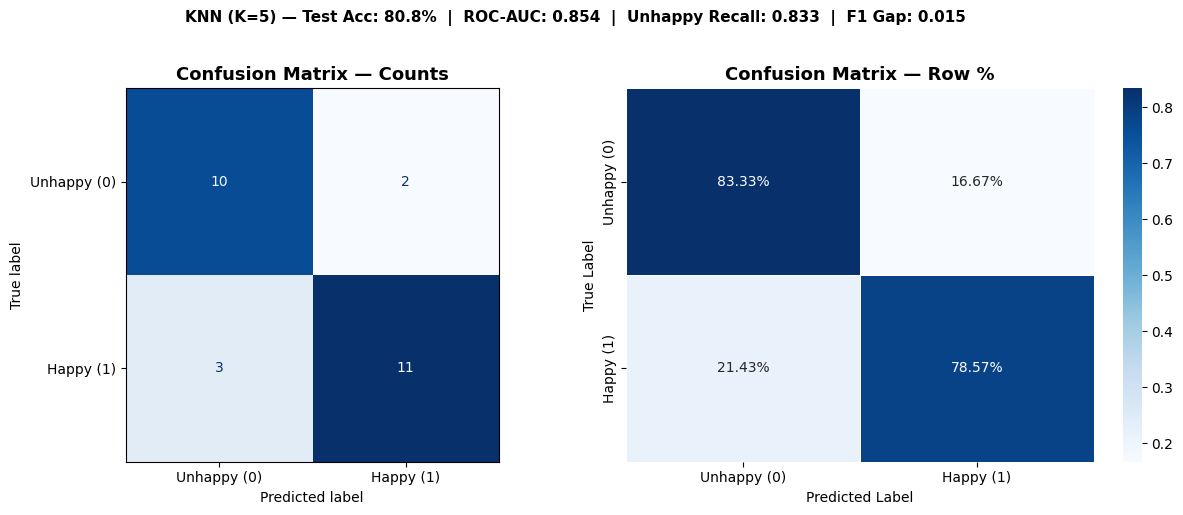


── Confusion Matrix Breakdown ──
True  Negative (TN) : 10  → Correctly predicted Unhappy
False Positive (FP) : 2  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 3  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 11  → Correctly predicted Happy

Recall  (Unhappy)   : 0.833  — of all actual Unhappy, % caught  ← primary focus
Recall  (Happy)     : 0.786  — of all actual Happy, % caught
Precision (Happy)   : 0.846  — of all 'Happy' predictions, % correct


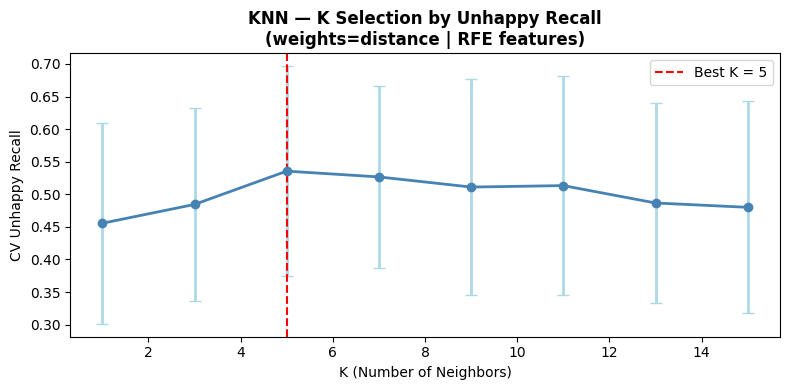

In [33]:
# ── KNN │ No SMOTE │ RFE Feature Selection │ Unhappy Recall Focus ────────────



# ── 1. Features (all 6, including X4 and X6 — let RFE decide) ────────────────
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']

model_df = df.copy()

# Feature Engineering
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols 

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. Scaling — KNN is distance based so scaling is required ─────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 4. RFE with LinearSVC as estimator ───────────────────────────────────────
# KNN has no feature_importances_ or coef_ so LinearSVC is used as RFE proxy
rfe = RFE(
    estimator=LinearSVC(C=1.0, max_iter=2000, random_state=42),
    n_features_to_select=3, step=1
)
rfe.fit(X_train_scaled, y_train)

selected_features = [all_features[i] for i in range(len(all_features)) if rfe.support_[i]]
print(f"\nTotal features before RFE : {len(all_features)}")
print(f"\n── RFE Feature Selection Results ──")
print(f"{'Feature':<25} {'Status':<15} {'Rank'}")
print("-" * 50)
for feat, rank, support in sorted(
    zip(all_features, rfe.ranking_, rfe.support_), key=lambda x: x[1]
):
    status = "✓  KEPT" if support else "✗  ELIMINATED"
    print(f"{feat:<25} {status:<15} Rank {rank}")

eliminated = [all_features[i] for i in range(len(all_features)) if not rfe.support_[i]]
print(f"\nKept       ({len(selected_features)})  : {selected_features}")
print(f"Eliminated ({len(eliminated)})  : {eliminated}")

X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe  = rfe.transform(X_test_scaled)

# ── 5. K Search — Unhappy Recall as scoring ───────────────────────────────────
# weights='distance' — closer neighbors get more vote, helps minority class
# This is KNN's built-in imbalance correction (no class_weight/sample_weight)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
unhappy_recall_scorer = make_scorer(recall_score, pos_label=0)

k_range       = [1, 3, 5, 7, 9, 11, 13, 15]
best_k        = None
best_recall   = -1
k_results     = []

print(f"\n── K Search (CV Unhappy Recall per K) ──")
for k in k_range:
    knn_k = KNeighborsClassifier(
        n_neighbors=k, metric='euclidean', weights='distance'
    )
    recall_k = cross_val_score(
        knn_k, X_train_rfe, y_train,
        cv=cv, scoring=unhappy_recall_scorer, n_jobs=-1
    )
    k_results.append((k, recall_k.mean(), recall_k.std()))
    print(f"  K={k:>2}  →  CV Unhappy Recall: {recall_k.mean():.4f}  ± {recall_k.std():.4f}")
    if recall_k.mean() > best_recall:
        best_recall = recall_k.mean()
        best_k      = k

print(f"✓ Best K = {best_k}  (CV Unhappy Recall = {best_recall:.4f})")

# ── 6. Final KNN model with best K ───────────────────────────────────────────
knn_model = KNeighborsClassifier(
    n_neighbors=best_k, metric='euclidean', weights='distance'
)

# ── 7. Cross-Validation with best K ──────────────────────────────────────────
cv_recall = cross_val_score(
    knn_model, X_train_rfe, y_train,
    cv=cv, scoring=unhappy_recall_scorer, n_jobs=-1
)
cv_auc = cross_val_score(
    knn_model, X_train_rfe, y_train,
    cv=cv, scoring='roc_auc', n_jobs=-1
)

print(f"\n── Cross-Validation Results (50 folds, K={best_k}) ──────────────")
print(f"CV Unhappy Recall  : {cv_recall.mean():.4f}  ± {cv_recall.std():.4f}  ← primary focus")
print(f"CV ROC-AUC         : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# ── 8. Train on Full Training Set & Evaluate on Test Set ─────────────────────
knn_model.fit(X_train_rfe, y_train)

y_pred      = knn_model.predict(X_test_rfe)
y_pred_prob = knn_model.predict_proba(X_test_rfe)[:, 1]

test_acc    = accuracy_score(y_test, y_pred)
test_auc    = roc_auc_score(y_test, y_pred_prob)
unhappy_rec = recall_score(y_test, y_pred, pos_label=0)
auc_gap     = test_auc - cv_auc.mean()

# F1 gap check
report_dict = classification_report(y_test, y_pred, output_dict=True)
f1_unhappy  = report_dict['0']['f1-score']
f1_happy    = report_dict['1']['f1-score']
f1_gap      = abs(f1_happy - f1_unhappy)

print(f"\n── Test Set Results ──────────────────────────────────────")
print(f"Test Accuracy      : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC       : {test_auc:.4f}")
print(f"Unhappy Recall(Y=0): {unhappy_rec:.4f}  ← primary focus")
print(f"CV AUC             : {cv_auc.mean():.4f}")
print(f"AUC Gap (overfit?) : {auc_gap:.4f}  {'⚠ overfit' if auc_gap > 0.10 else '✓ ok'}")
print(f"\nF1 — Unhappy(0)    : {f1_unhappy:.4f}")
print(f"F1 — Happy(1)      : {f1_happy:.4f}")
print(f"F1 Gap             : {f1_gap:.4f}  {'✓ balanced' if f1_gap <= 0.05 else '⚠ gap > 0.05'}")

# ── 9. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 10. Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'KNN (K={best_k}) — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  '
    f'Unhappy Recall: {unhappy_rec:.3f}  |  F1 Gap: {f1_gap:.3f}',
    fontsize=11, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('PLOTS/knn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 11. Confusion Matrix Breakdown ───────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nRecall  (Unhappy)   : {tn/(tn+fp):.3f}  — of all actual Unhappy, % caught  ← primary focus")
print(f"Recall  (Happy)     : {tp/(tp+fn):.3f}  — of all actual Happy, % caught")
print(f"Precision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")

# ── 12. K Search Summary Plot ─────────────────────────────────────────────────
k_vals, k_recalls, k_stds = zip(*k_results)

plt.figure(figsize=(8, 4))
plt.errorbar(k_vals, k_recalls, yerr=k_stds, fmt='-o',
             color='steelblue', ecolor='lightblue', capsize=4, linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', linewidth=1.5,
            label=f'Best K = {best_k}')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('CV Unhappy Recall')
plt.title('KNN — K Selection by Unhappy Recall\n(weights=distance | RFE features)',
          fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('PLOTS/knn_k_search.png', dpi=150, bbox_inches='tight')
plt.show()

── Model Feature Sets ──
KNN features : ['X1', 'X2', 'X5']  (K=13, weight=2)
RF  features : ['X1', 'X3', 'X5']   (weight=2)
Overlapping  : ['X1', 'X5']

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

KNN input shape (train): (100, 3)  → scaled
RF  input shape (train): (100, 3)  → unscaled

── Cross-Validation (50 folds) — KNN, RF, and Ensemble ──

Model                            Recall-U   Recall-H    F1-U    F1-H   F1-Gap     AUC
--------------------------------------------------------------------------------
KNN  (K=13) ['X1', 'X2', 'X5']      0.389      0.789   0.465   0.688    0.223   0.604
RF   ['X1', 'X3', 'X5']             0.687      0.560   0.609   0.614    0.071   0.608
Ensemble (2:2)                      0.520      0.676   0.536   0.652    0.118   0.624

── Threshold Sweep Results ──
Objective  : 0.65 × Unhappy Recall  −  0.35 × |F1 Gap|
Constraint : Happy Recall ≥ 64%

 Thresh   Recall-U   Recall-H    F1-U    F1-H   F1-Gap    Score


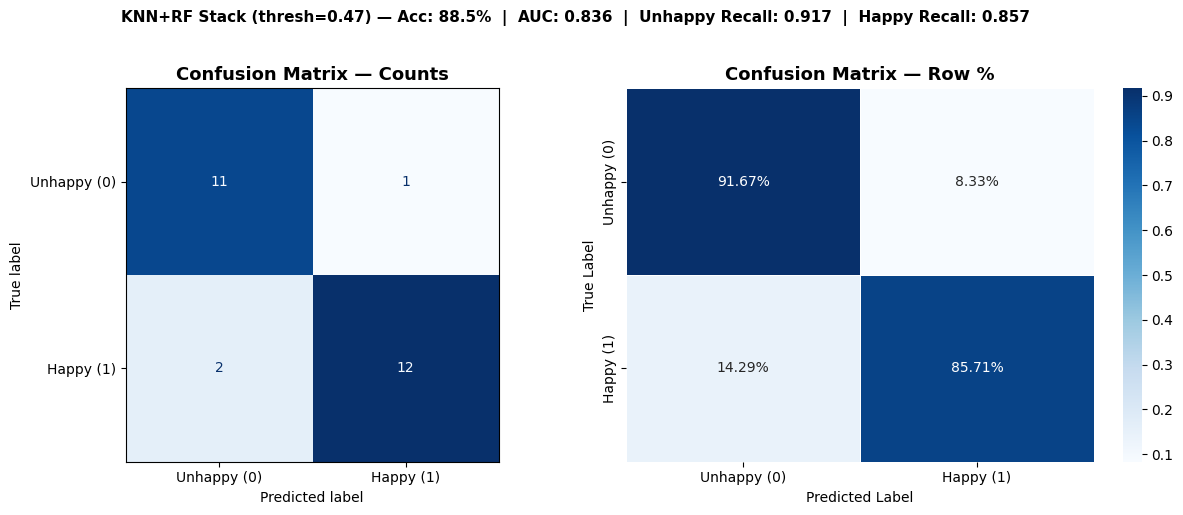


── Confusion Matrix Breakdown ──
True  Negative (TN) : 11  → Correctly predicted Unhappy
False Positive (FP) : 1  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 2  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 12  → Correctly predicted Happy

Recall  (Unhappy)   : 0.917  ← primary focus
Recall  (Happy)     : 0.857
Precision (Happy)   : 0.923


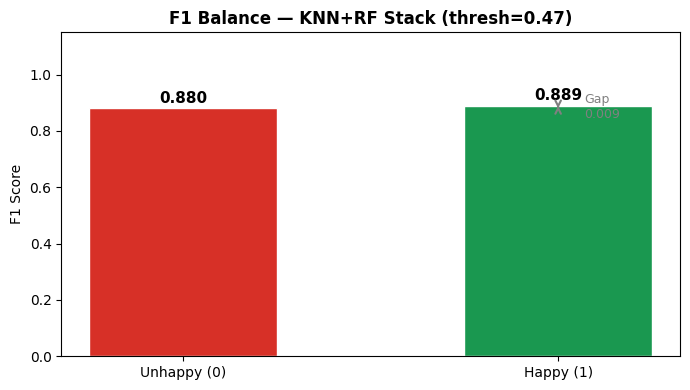

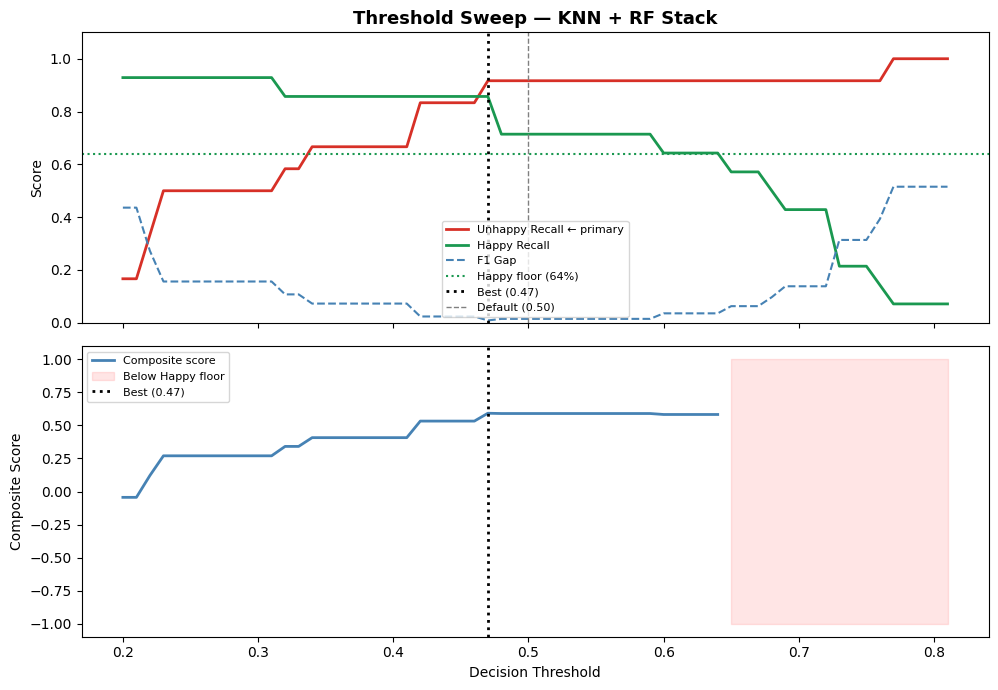

In [34]:
# ── Stacking │ KNN + Random Forest │ Manual Features Per Model │ Unhappy Recall + Happy Balance ──
#
# KNN  → distance-based, needs scaling, sensitive to feature choice
# RF   → tree-based, no scaling needed, class_weight handles imbalance
#
# Each model gets its OWN independent feature set — you control both separately.
# Soft-vote: Final P(Happy) = (W_KNN × knn_prob + W_RF × rf_prob) / (W_KNN + W_RF)
# Then threshold sweep finds the best decision boundary.


# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']

model_df = df.copy().reset_index(drop=True)
model_df = model_df.drop(
    columns=['avg_score', 'satisfied_count', 'unsatisfied_count', 'score_std'],
    errors='ignore'
)
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

# ═════════════════════════════════════════════════════════════════════════════
# ── MANUAL FEATURE SELECTION — edit these two lists independently ─────────────
#
# KNN_FEATURES  → features for the KNN model
#   KNN is distance-based so fewer, well-separated features work better
#   From your RFE results: top 3 features selected by LinearSVC proxy
#
# RF_FEATURES   → features for the Random Forest model
#   RF is tree-based — can handle more features without scaling issues
#   From your manual experiments: X1 X3 X5 gave 11 Unhappy correct
#
# Available: 'X1', 'X2', 'X3', 'X4', 'X5', 'X6'
# They can overlap — both models can share some features, that is fine
# ─────────────────────────────────────────────────────────────────────────────
KNN_FEATURES = ['X1','X2','X5']   # ← edit this for KNN
RF_FEATURES  = ['X1','X3','X5']   # ← edit this for RF
# ═════════════════════════════════════════════════════════════════════════════

# ── VOTING WEIGHTS — edit these ───────────────────────────────────────────────
# Higher WEIGHT_KNN → KNN's probability contributes more to the final vote
# Higher WEIGHT_RF  → RF's probability contributes more to the final vote
# Start equal (2:2), adjust based on which model performs better in CV table
WEIGHT_KNN = 2   # weight for KNN model
WEIGHT_RF  = 2   # weight for RF model
# ─────────────────────────────────────────────────────────────────────────────

# ── KNN K VALUE — edit this ───────────────────────────────────────────────────
# From your original KNN code the best K was found via CV search.
# Set it here directly — run a quick K search below if unsure.
# Odd numbers preferred to avoid tie votes: 3, 5, 7, 9, 11
KNN_K = 13  # ← set your best K here
# ─────────────────────────────────────────────────────────────────────────────

print(f"── Model Feature Sets ──")
print(f"KNN features : {KNN_FEATURES}  (K={KNN_K}, weight={WEIGHT_KNN})")
print(f"RF  features : {RF_FEATURES}   (weight={WEIGHT_RF})")
print(f"Overlapping  : {[f for f in KNN_FEATURES if f in RF_FEATURES]}")

y = model_df['Y'].reset_index(drop=True)

# ── 2. Train / Test Split — same split for both models ───────────────────────
# Both models must see IDENTICAL train/test rows — same random_state guarantees this
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y
)

y_train   = y.iloc[idx_train].reset_index(drop=True)
y_test    = y.iloc[idx_test].reset_index(drop=True)
y_train_arr = y_train.to_numpy()
y_test_arr  = y_test.to_numpy()

print(f"\nTrain size : {len(y_train)} rows")
print(f"Test  size : {len(y_test)}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. Prepare Feature Matrices for Each Model ────────────────────────────────
# KNN → needs StandardScaler (distance-based — unscaled features distort distances)
# RF  → no scaling needed (tree splits are threshold-based, not distance-based)

# Raw feature matrices
X_knn_raw = model_df[KNN_FEATURES].reset_index(drop=True)
X_rf_raw  = model_df[RF_FEATURES].reset_index(drop=True)

# Train/test split for KNN (raw — will be scaled below)
X_knn_train_raw = X_knn_raw.iloc[idx_train].reset_index(drop=True)
X_knn_test_raw  = X_knn_raw.iloc[idx_test].reset_index(drop=True)

# Train/test split for RF (no scaling)
X_rf_train = X_rf_raw.iloc[idx_train].reset_index(drop=True)
X_rf_test  = X_rf_raw.iloc[idx_test].reset_index(drop=True)

# Scale KNN features — fit scaler on train only to prevent data leakage
scaler          = StandardScaler()
X_knn_train     = scaler.fit_transform(X_knn_train_raw)
X_knn_test      = scaler.transform(X_knn_test_raw)

X_rf_train_arr  = X_rf_train.to_numpy()
X_rf_test_arr   = X_rf_test.to_numpy()

print(f"\nKNN input shape (train): {X_knn_train.shape}  → scaled")
print(f"RF  input shape (train): {X_rf_train_arr.shape}  → unscaled")

# ── 4. Define Both Models ─────────────────────────────────────────────────────
#
# KNN:
#   weights='distance' → closer neighbors vote more → helps minority class
#   metric='euclidean' → standard distance for scaled features
#   No class_weight parameter in KNN — distance weighting is the imbalance lever
#
# RF:
#   class_weight='balanced' → upweights Unhappy rows natively
#   Shallow depth + min_samples_leaf → avoids memorising Happy majority

knn_model = KNeighborsClassifier(
    n_neighbors = KNN_K,
    metric      = 'euclidean',
    weights     = 'distance'     # closer neighbors get more vote → helps Unhappy
)

rf_model = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 4,
    min_samples_leaf = 5,
    max_features     = 'sqrt',
    class_weight     = 'balanced',   # upweights Unhappy natively
    random_state     = 42,
    n_jobs           = -1
)


# ── 5. Cross-Validation — evaluate each model and combined ensemble ───────────
print(f"\n── Cross-Validation (50 folds) — KNN, RF, and Ensemble ──")

cv_final = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

metrics = {
    'knn'     : {'ur': [], 'hr': [], 'f1u': [], 'f1h': [], 'auc': []},
    'rf'      : {'ur': [], 'hr': [], 'f1u': [], 'f1h': [], 'auc': []},
    'ensemble': {'ur': [], 'hr': [], 'f1u': [], 'f1h': [], 'auc': []},
}

for train_idx, val_idx in cv_final.split(X_knn_train, y_train_arr):
    # KNN fold — already scaled
    Xk_tr,  Xk_val = X_knn_train[train_idx],  X_knn_train[val_idx]
    # RF fold — unscaled numpy
    Xr_tr,  Xr_val = X_rf_train_arr[train_idx], X_rf_train_arr[val_idx]
    y_tr,   y_val  = y_train_arr[train_idx],     y_train_arr[val_idx]

    knn_model.fit(Xk_tr, y_tr)
    rf_model.fit(Xr_tr,  y_tr)

    prob_knn = knn_model.predict_proba(Xk_val)[:, 1]
    prob_rf  = rf_model.predict_proba(Xr_val)[:, 1]
    prob_ens = (WEIGHT_KNN * prob_knn + WEIGHT_RF * prob_rf) / (WEIGHT_KNN + WEIGHT_RF)

    for tag, pred_prob in [('knn',      prob_knn),
                           ('rf',       prob_rf),
                           ('ensemble', prob_ens)]:
        pred = (pred_prob >= 0.5).astype(int)
        metrics[tag]['ur'].append(recall_score(y_val, pred, pos_label=0, zero_division=0))
        metrics[tag]['hr'].append(recall_score(y_val, pred, pos_label=1, zero_division=0))
        metrics[tag]['f1u'].append(f1_score(y_val,   pred, pos_label=0, zero_division=0))
        metrics[tag]['f1h'].append(f1_score(y_val,   pred, pos_label=1, zero_division=0))
        metrics[tag]['auc'].append(roc_auc_score(y_val, pred_prob))

print(f"\n{'Model':<30} {'Recall-U':>10} {'Recall-H':>10} {'F1-U':>7} {'F1-H':>7} {'F1-Gap':>8} {'AUC':>7}")
print("-" * 80)
cv_labels = {
    'knn':      f'KNN  (K={KNN_K}) {KNN_FEATURES}',
    'rf':       f'RF   {RF_FEATURES}',
    'ensemble': f'Ensemble ({WEIGHT_KNN}:{WEIGHT_RF})',
}
for tag, label in cv_labels.items():
    m   = metrics[tag]
    ur  = np.mean(m['ur']);  hr  = np.mean(m['hr'])
    f1u = np.mean(m['f1u']); f1h = np.mean(m['f1h'])
    gap = np.mean([abs(h - u) for h, u in zip(m['f1h'], m['f1u'])])
    auc = np.mean(m['auc'])
    print(f"{label:<30} {ur:>10.3f} {hr:>10.3f} {f1u:>7.3f} {f1h:>7.3f} {gap:>8.3f} {auc:>7.3f}")

# ── 6. Train on Full Training Set ─────────────────────────────────────────────
knn_model.fit(X_knn_train, y_train_arr)
rf_model.fit(X_rf_train_arr, y_train_arr)

prob_knn_test = knn_model.predict_proba(X_knn_test)[:, 1]
prob_rf_test  = rf_model.predict_proba(X_rf_test_arr)[:, 1]
prob_ens_test = (WEIGHT_KNN * prob_knn_test + WEIGHT_RF * prob_rf_test) / (WEIGHT_KNN + WEIGHT_RF)

# ── 7. Threshold Sweep ────────────────────────────────────────────────────────
# ── Tune these three knobs ────────────────────────────────────────────────────
ALPHA            = 0.65   # weight on Unhappy Recall  (↑ = more Unhappy focused)
BETA             = 0.35   # penalty on F1 gap          (↑ = more balanced)
MIN_HAPPY_RECALL = 0.64   # Happy Recall floor          (↑ = Happy protected more)
# ─────────────────────────────────────────────────────────────────────────────

thresholds    = np.arange(0.20, 0.81, 0.01)
best_score    = -np.inf
best_thresh   = 0.5
threshold_log = []

for thresh in thresholds:
    y_pred_t  = (prob_ens_test >= thresh).astype(int)
    ur        = recall_score(y_test_arr, y_pred_t, pos_label=0, zero_division=0)
    hr        = recall_score(y_test_arr, y_pred_t, pos_label=1, zero_division=0)
    f1u       = f1_score(y_test_arr,    y_pred_t, pos_label=0, zero_division=0)
    f1h       = f1_score(y_test_arr,    y_pred_t, pos_label=1, zero_division=0)
    gap       = abs(f1h - f1u)
    composite = ALPHA * ur - BETA * gap if hr >= MIN_HAPPY_RECALL else -np.inf

    threshold_log.append({
        'threshold': thresh, 'unhappy_recall': ur, 'happy_recall': hr,
        'f1_unhappy': f1u, 'f1_happy': f1h, 'f1_gap': gap, 'composite': composite
    })
    if composite > best_score:
        best_score  = composite
        best_thresh = thresh

thresh_df = pd.DataFrame(threshold_log)

print(f"\n── Threshold Sweep Results ──")
print(f"Objective  : {ALPHA} × Unhappy Recall  −  {BETA} × |F1 Gap|")
print(f"Constraint : Happy Recall ≥ {MIN_HAPPY_RECALL:.0%}")
print(f"\n{'Thresh':>7} {'Recall-U':>10} {'Recall-H':>10} {'F1-U':>7} {'F1-H':>7} {'F1-Gap':>8} {'Score':>8}")
print("-" * 60)
for _, row in thresh_df[thresh_df['composite'] > -np.inf].iterrows():
    marker = " ← BEST" if abs(row['threshold'] - best_thresh) < 0.001 else ""
    print(f"{row['threshold']:>7.2f} {row['unhappy_recall']:>10.3f} {row['happy_recall']:>10.3f} "
          f"{row['f1_unhappy']:>7.3f} {row['f1_happy']:>7.3f} {row['f1_gap']:>8.3f} "
          f"{row['composite']:>8.4f}{marker}")

# ── 8. Final Predictions ──────────────────────────────────────────────────────
y_pred = (prob_ens_test >= best_thresh).astype(int)

test_acc        = accuracy_score(y_test_arr, y_pred)
test_auc        = roc_auc_score(y_test_arr, prob_ens_test)
unhappy_rec     = recall_score(y_test_arr, y_pred,  pos_label=0)
happy_rec       = recall_score(y_test_arr, y_pred,  pos_label=1)
f1_unhappy_test = f1_score(y_test_arr, y_pred,      pos_label=0)
f1_happy_test   = f1_score(y_test_arr, y_pred,      pos_label=1)
f1_gap_test     = abs(f1_happy_test - f1_unhappy_test)

print(f"\n── Test Set Results (threshold = {best_thresh:.2f}) ──")
print(f"KNN features          : {KNN_FEATURES}  (K={KNN_K})")
print(f"RF  features          : {RF_FEATURES}")
print(f"Test Accuracy         : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC          : {test_auc:.4f}")
print(f"Unhappy Recall (Y=0)  : {unhappy_rec:.4f}  ← primary focus")
print(f"Happy   Recall (Y=1)  : {happy_rec:.4f}")
print(f"Unhappy F1     (Y=0)  : {f1_unhappy_test:.4f}")
print(f"Happy   F1     (Y=1)  : {f1_happy_test:.4f}")
print(f"F1 Gap |Happy-Unhappy|: {f1_gap_test:.4f}  (target < 0.10)")

# ── 9. Individual vs Ensemble Comparison ────────────────────────────────────
print(f"\n── Model Comparison on Test Set ──")
print(f"{'Model':<32} {'Recall-U':>10} {'Recall-H':>10} {'F1-U':>7} {'F1-H':>7} {'F1-Gap':>8} {'AUC':>7}")
print("-" * 84)
for name, pred_prob in [
    (f'KNN  (K={KNN_K}) {KNN_FEATURES}',          prob_knn_test),
    (f'RF   {RF_FEATURES}',                        prob_rf_test),
    (f'Ensemble ({WEIGHT_KNN}:{WEIGHT_RF})',        prob_ens_test),
]:
    pred = (pred_prob >= best_thresh).astype(int)
    ru   = recall_score(y_test_arr, pred, pos_label=0)
    rh   = recall_score(y_test_arr, pred, pos_label=1)
    f1u  = f1_score(y_test_arr,    pred, pos_label=0)
    f1h  = f1_score(y_test_arr,    pred, pos_label=1)
    gap  = abs(f1h - f1u)
    auc  = roc_auc_score(y_test_arr, pred_prob)
    print(f"{name:<32} {ru:>10.3f} {rh:>10.3f} {f1u:>7.3f} {f1h:>7.3f} {gap:>8.3f} {auc:>7.3f}")

# ── 10. Classification Report ─────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(y_test_arr, y_pred, target_names=['Unhappy (0)', 'Happy (1)']))

# ── 11. Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test_arr, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'KNN+RF Stack (thresh={best_thresh:.2f}) — '
    f'Acc: {test_acc*100:.1f}%  |  AUC: {test_auc:.3f}  |  '
    f'Unhappy Recall: {unhappy_rec:.3f}  |  Happy Recall: {happy_rec:.3f}',
    fontsize=11, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('knn_rf_stack_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nRecall  (Unhappy)   : {tn/(tn+fp):.3f}  ← primary focus")
print(f"Recall  (Happy)     : {tp/(tp+fn):.3f}")
print(f"Precision (Happy)   : {tp/(tp+fp):.3f}")

# ── 12. F1 Balance Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
f1_vals = [f1_unhappy_test, f1_happy_test]
bars = ax.bar(['Unhappy (0)', 'Happy (1)'], f1_vals,
              color=['#d73027', '#1a9850'], edgecolor='white', width=0.5)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 Score')
ax.set_title(f'F1 Balance — KNN+RF Stack (thresh={best_thresh:.2f})',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.annotate('', xy=(1, f1_happy_test), xytext=(1, f1_unhappy_test),
            arrowprops=dict(arrowstyle='<->', color='grey', lw=1.5))
ax.text(1.07, (f1_happy_test + f1_unhappy_test) / 2,
        f'Gap\n{f1_gap_test:.3f}', va='center', fontsize=9, color='grey')
plt.tight_layout()
plt.savefig('knn_rf_stack_f1_balance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 13. Threshold Sweep Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(thresh_df['threshold'], thresh_df['unhappy_recall'],
             color='#d73027', linewidth=2, label='Unhappy Recall ← primary')
axes[0].plot(thresh_df['threshold'], thresh_df['happy_recall'],
             color='#1a9850', linewidth=2, label='Happy Recall')
axes[0].plot(thresh_df['threshold'], thresh_df['f1_gap'],
             color='steelblue', linewidth=1.5, linestyle='--', label='F1 Gap')
axes[0].axhline(MIN_HAPPY_RECALL, color='#1a9850', linestyle=':', linewidth=1.5,
                label=f'Happy floor ({MIN_HAPPY_RECALL:.0%})')
axes[0].axvline(best_thresh, color='black', linestyle=':', linewidth=2,
                label=f'Best ({best_thresh:.2f})')
axes[0].axvline(0.50, color='grey', linestyle='--', linewidth=1, label='Default (0.50)')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold Sweep — KNN + RF Stack', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.1)

valid_mask = thresh_df['composite'] > -np.inf
axes[1].plot(thresh_df.loc[valid_mask, 'threshold'],
             thresh_df.loc[valid_mask, 'composite'],
             color='steelblue', linewidth=2, label='Composite score')
if (~valid_mask).any():
    axes[1].fill_between(thresh_df.loc[~valid_mask, 'threshold'],
                         -1, 1, alpha=0.1, color='red', label='Below Happy floor')
axes[1].axvline(best_thresh, color='black', linestyle=':', linewidth=2,
                label=f'Best ({best_thresh:.2f})')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Composite Score')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('knn_rf_stack_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

The foundation — X1 and X5 (shared by both models)

"My order arrived on time" and "I am satisfied with my courier" are the two pillars that both models agree on. These are the baseline signals. A customer who scores low on both is almost certainly Unhappy regardless of anything else. A customer who scores high on both is in the safe zone — but not confirmed Happy yet. The interesting differentiation happens in the third feature each model uses.

Why X3 is the Unhappy detector

"I ordered everything I wanted to order" sounds like it should be a positive signal, but think about what a low score on X3 actually means — the customer couldn't find, or couldn't add, everything they wanted. That frustration happened before the courier even picked up the package. It is a structural complaint about catalogue completeness, stock availability, or the ordering process itself. A customer who had a fine delivery (X1 and X5 are okay) but couldn't get what they actually wanted is left with a lingering dissatisfaction that delivery quality alone can't fix. The RF model picks this up because tree-based splits are good at isolating these "everything else was fine but this one thing wasn't" patterns. X3 being low is almost definitionally Unhappy — you went to order something and left without it.

Why X2 is the Happy confirmer

"The contents of my order were as I expected" is a post-delivery relief signal. When this is high, it means the customer opened the box and found exactly what they ordered — no substitutions, no damaged items, no surprises. This is the moment the entire experience gets sealed positively in their mind. KNN picks this up because it finds neighbors in euclidean distance space — customers who score similarly on X1, X2, and X5 tend to cluster together, and the cluster where all three are high is strongly Happy. X2 acts as the final confirmation: the delivery was on time, the courier was good, and the box contained what was promised.

Why they are different features for different models — the deeper reason

X3 captures a gap between desire and supply — a feeling that starts at the browsing or checkout stage. X2 captures a gap between expectation and reality — a feeling that arrives at the doorstep. These are two completely separate moments in the customer journey. Unhappy customers typically feel let down at the ordering stage (X3). Happy customers confirm their satisfaction at the delivery stage (X2). The ensemble uses both, letting each model contribute the signal it is best positioned to detect. 